In [1]:
import os
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = "data/raw"


In [2]:
# if not os.path.exists(DATA_DIR):
#     raise Exception(" Không tìm thấy thư mục data/raw")

# print(" Dataset path OK:", DATA_DIR)

BASE_DIR = Path.cwd().parent      # ric_cv
DATA_DIR = BASE_DIR / "data" / "raw"

assert DATA_DIR.exists(), " Không tìm thấy data/raw"
print(" Dataset path OK:", DATA_DIR)


 Dataset path OK: D:\Python Projects\RicAI_CV\ric_cv\data\raw


In [3]:
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]

print(" Các class hiện có:")
for c in classes:
    print("-", c)


 Các class hiện có:
- Bacterial Leaf Blight
- Barrow Brown Leaf Spot
- Brown Spot
- Healthy Rice Leaf
- Leaf Blast
- Leaf Scald
- Leaf Smut
- Neck Blast
- Rice Hispa
- Sheath Blight
- Tungro


In [4]:
print(" Số lượng ảnh mỗi class:\n")

for c in classes:
    class_path = os.path.join(DATA_DIR, c)
    images = os.listdir(class_path)
    print(f"{c:25s}: {len(images)} ảnh")


 Số lượng ảnh mỗi class:

Bacterial Leaf Blight    : 3637 ảnh
Barrow Brown Leaf Spot   : 1071 ảnh
Brown Spot               : 4712 ảnh
Healthy Rice Leaf        : 3383 ảnh
Leaf Blast               : 5104 ảnh
Leaf Scald               : 2149 ảnh
Leaf Smut                : 40 ảnh
Neck Blast               : 1000 ảnh
Rice Hispa               : 1514 ảnh
Sheath Blight            : 2532 ảnh
Tungro                   : 1308 ảnh


In [5]:
sample_class = classes[0]
sample_img_name = os.listdir(os.path.join(DATA_DIR, sample_class))[0]
sample_img_path = os.path.join(DATA_DIR, sample_class, sample_img_name)

img = cv2.imread(sample_img_path)
h, w, c = img.shape

print(" Ảnh mẫu:")
print("Class:", sample_class)
print("Kích thước:", h, "x", w)
print("Channels:", c)


 Ảnh mẫu:
Class: Bacterial Leaf Blight
Kích thước: 1600 x 1200
Channels: 3


(-0.5, 1199.5, 1599.5, -0.5)

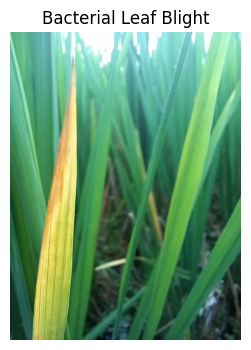

In [6]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4,4))
plt.imshow(img_rgb)
plt.title(sample_class)
plt.axis("off")


In [7]:
## Nhận xét dataset
#- Dataset gồm 11 loại lá lúa (10 bệnh + 1 khỏe mạnh)
#- Kích thước ảnh không đồng nhất
# - Số lượng ảnh giữa các class có thể mất cân bằng
# - Cần resize + chuẩn hóa trước khi train
